Zadaniem będzie przetworzenie danych Titanica. Spróbujcie zgrupować pasażerów Titanica, używając różnych informacji. Poniżej podano kilka pomysłów i wskazówek. Nie jesteście zobowiązani do zastosowania wszystkich. Po prostu pobawcie się danymi i spróbujcie znaleźć również zaskakujące informacje.

- Jeśli gdzieś brakuje nam danych, możecie je pominąć.
- Możecie pominąć niektóre dane kategoryczne (na przykład kabinę i nazwisko).
- Najpierw nie bierzcie pod uwagę faktu, czy pasażer przeżył, ale po klasteryzacji porównajcie klastry z tą  informacją. Znajdźcie dobrą liczbę klastrów dla  k -średnich. Znajdźcie najbardziej użyteczny podzbiór cech do klasteryzacji.
- Następnie użyjcie informacji, czy pasażer survived (przeżył). Czy to poprawia klasteryzację?
- Rozważcie normalizację danych numerycznych.
- Kontynuujcie pracę z danymi Titanica:

Zbudujcie model klasyfikacyjny do przewidywania przeżywalności.
- Nie bazujcie na cechach samych w sobie, ale zastosujcie PCA i sprawdźcie, czy to poprawia wyniki.
- Użyjcie potoków (pipelines).

Następnie, ponownie kontynuujcie pracę z danymi Titanica:

- Znajdźcie potencjalne wartości odstające na podstawie klasteryzacji.
- Znajdźcie potencjalne wartości odstające na podstawie modelowania gaussowskiego.

In [1]:
#@title Przydatne importy

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme()

# Data processing
import numpy as np
import pandas as pd

# Download from Google Drive
import gdown

# Generation of synthetic data
from sklearn.datasets import make_blobs

# Clustering
## k-means
from sklearn.cluster import KMeans
## with Gaussian mixtures
from sklearn.mixture import GaussianMixture

# Data transformation
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
## PCA
from sklearn import decomposition

# Data preparation for learning, model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

# Some basic and known models
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression

# Processing pipelining
from sklearn.pipeline import Pipeline

# Quality indicators
from sklearn import metrics
from sklearn.metrics import confusion_matrix

In [6]:
titanic=pd.read_csv('titanic.csv')

# from sklearn.datasets import fetch_openml
# titanic_data = fetch_openml("titanic",version=1, as_frame=True)
# titanic = titanic_data['frame']

titanic.head(n=3)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250


In [50]:
from sklearn.preprocessing import OneHotEncoder

sex_column=titanic[['Sex']].fillna('Missing')
encoder=OneHotEncoder(drop='first',sparse_output=False)

sex_encoded=encoder.fit_transform(sex_column)

sex_encoded_df=pd.DataFrame(sex_encoded,columns=['Sex_'+str(i) for i in range(sex_encoded.shape[1])])

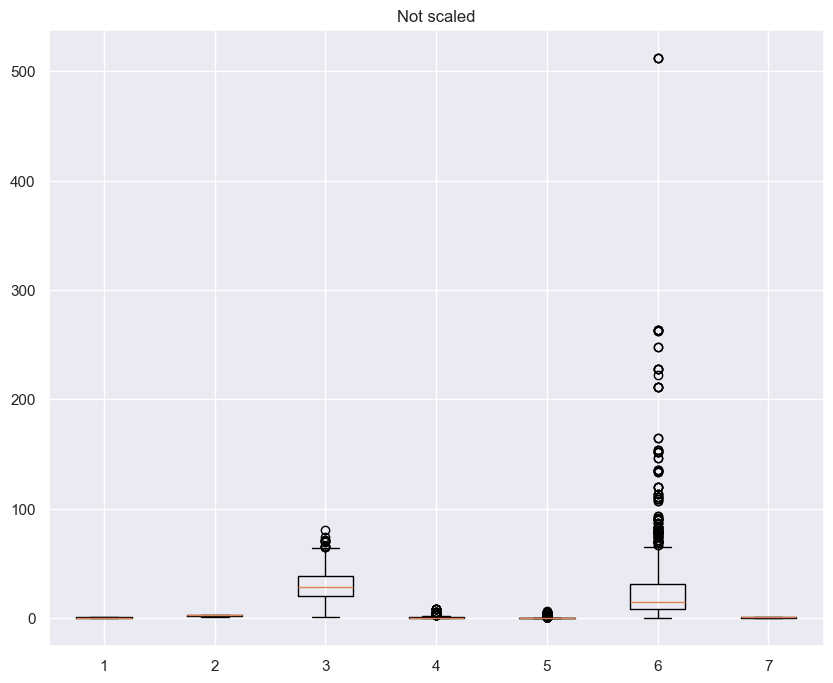

In [51]:
# Basic information.

# Display basic information
titanic.head(n=3)
titanic.describe()
# titanic_survived=titanic[['Survived']]

# Select all numerical columns (float and int types)
numeric_titanic = titanic.select_dtypes(include=np.number)
numeric_titanic=titanic.select_dtypes(include=np.number).join(sex_encoded_df)

numeric_titanic = numeric_titanic.dropna()


plt.figure(figsize=(10, 8))
plt.boxplot(numeric_titanic.to_numpy())
# plt.xticks(np.arange(1,len(scaled_data.columns)+1),scaled_data.columns,rotation=90)
plt.title("Not scaled")
plt.show()

# print(titanic_survived)

<Figure size 800x800 with 0 Axes>

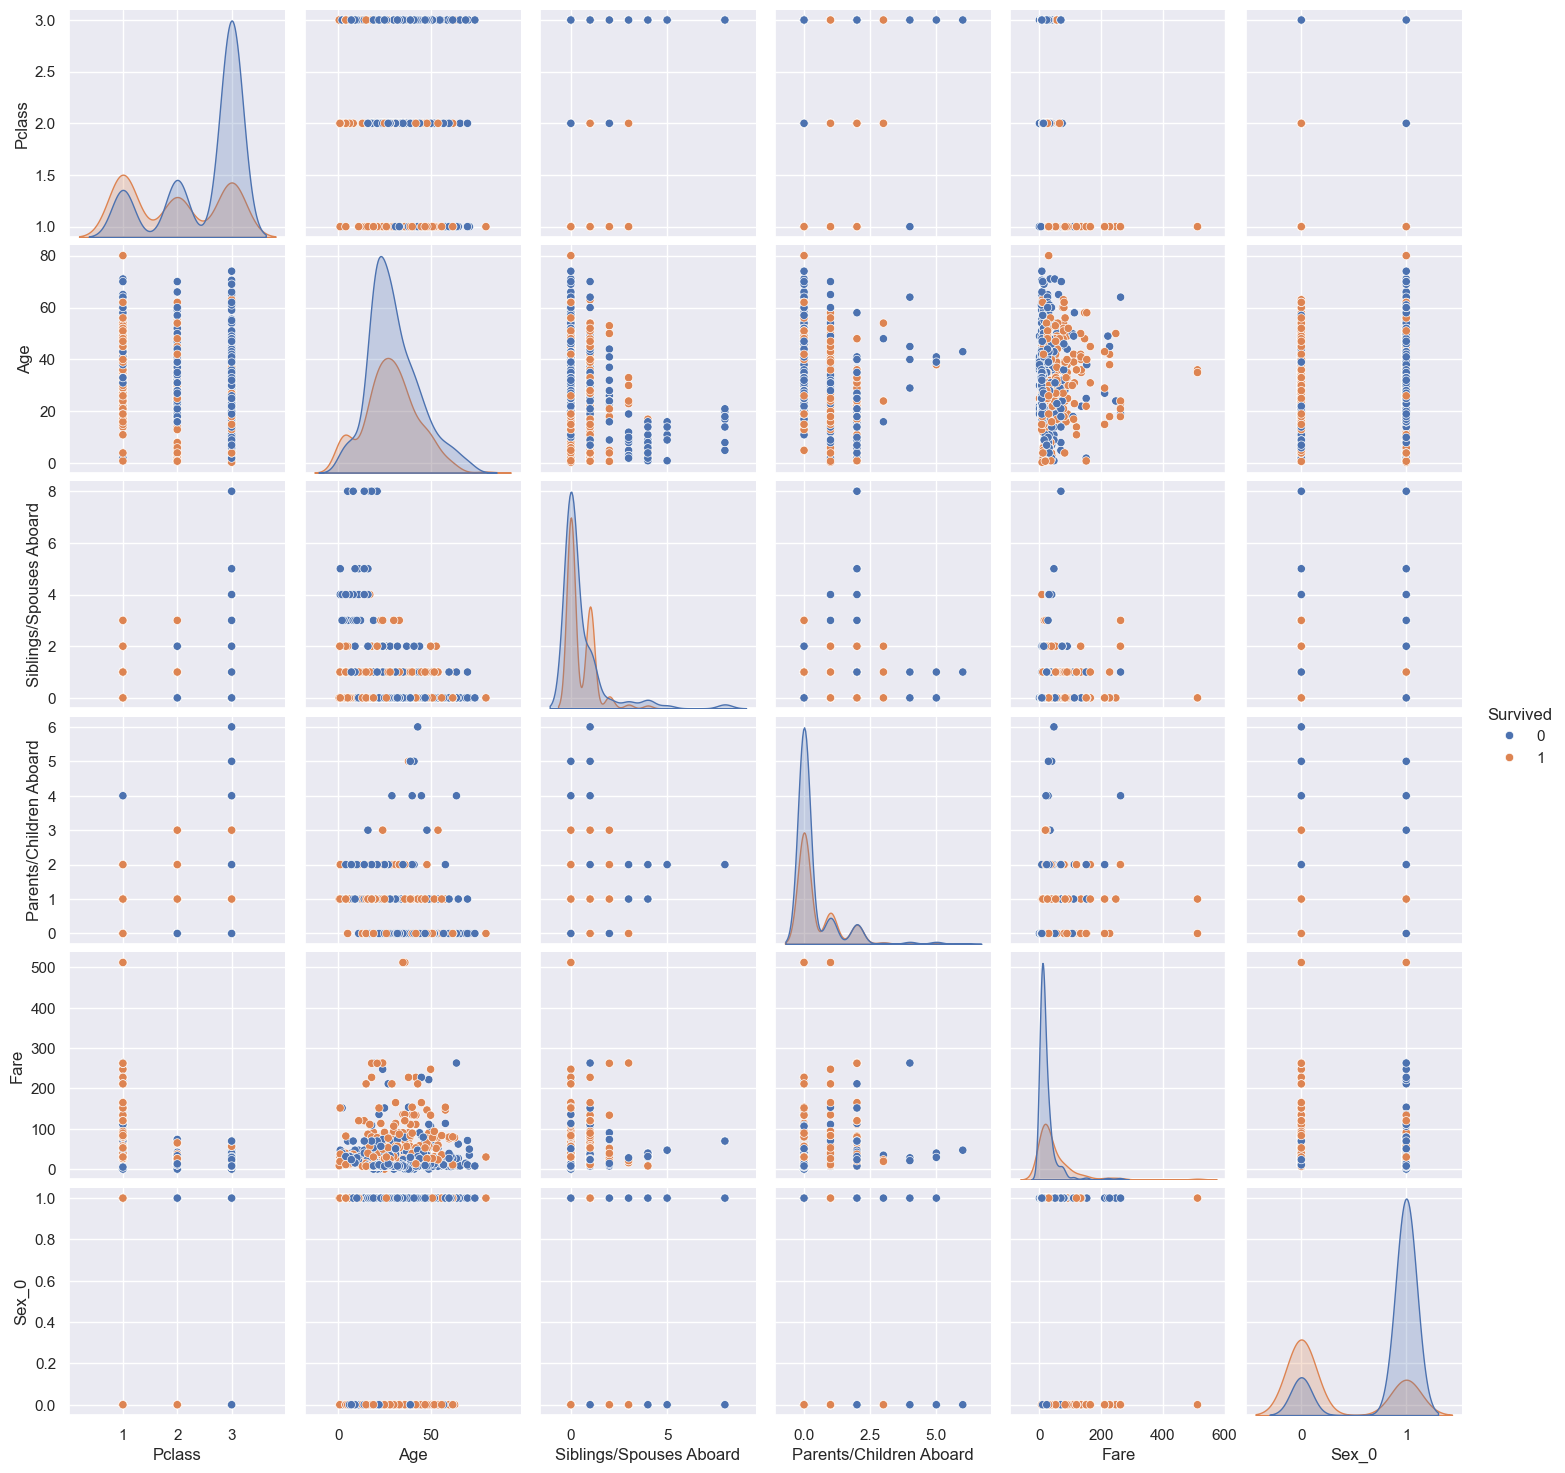

In [53]:
plt.figure(figsize=(8, 8))
sns.pairplot(numeric_titanic, hue='Survived')
plt.show()

Survived                    1.0000
Pclass                      1.0000
Age                        17.7500
Siblings/Spouses Aboard     1.0000
Parents/Children Aboard     0.0000
Fare                       23.2125
Sex_0                       1.0000
dtype: float64


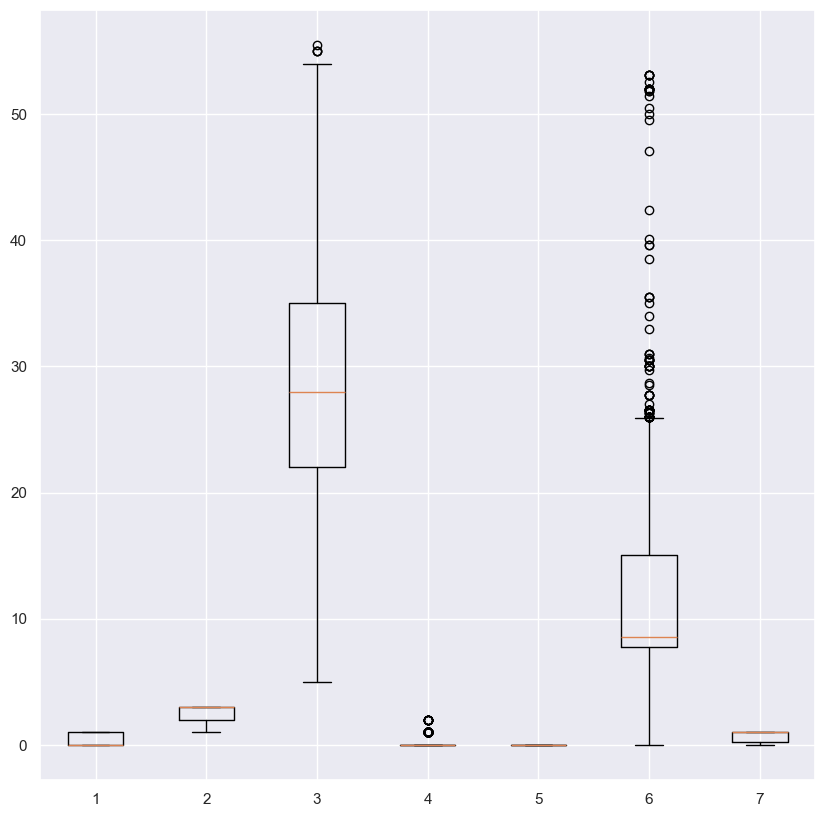

In [54]:
# defining and removing outliers
titanic_col_names=list(titanic)

q1=numeric_titanic.quantile(0.25)

q3=numeric_titanic.quantile(0.75)

iqr=q3-q1
print(iqr)

cutoff=iqr*2/3

lower_band=q1-iqr
higher_band=q3+iqr

titanic_no_outliers=numeric_titanic[~((numeric_titanic<lower_band)|(numeric_titanic>higher_band)).any(axis=1)]

plt.figure(figsize=(10, 10))
ax = plt.axes()
feat = titanic_no_outliers
plt.boxplot(feat)
# ax.set_xticklabels(wine_col_names_features)
plt.show()

<Figure size 640x480 with 0 Axes>

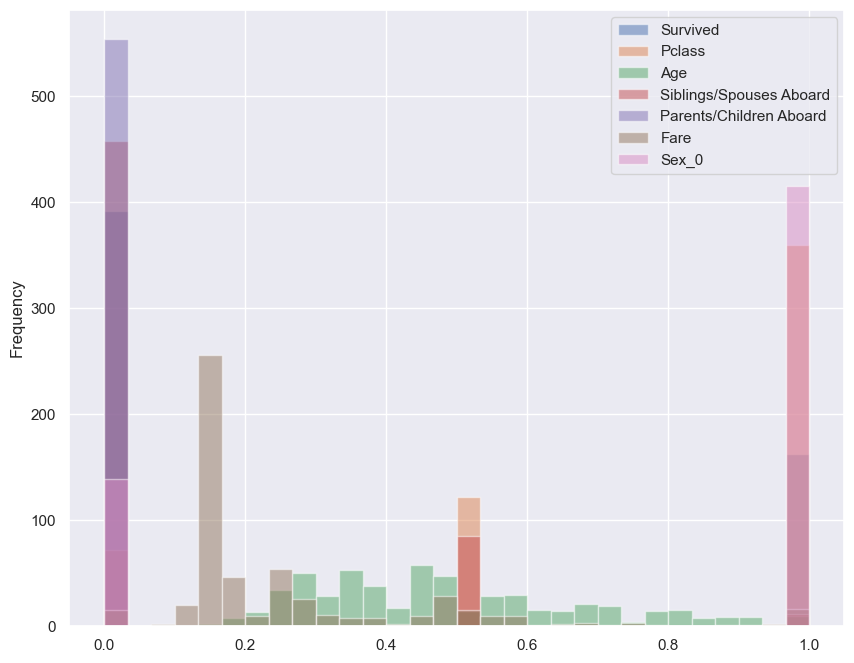

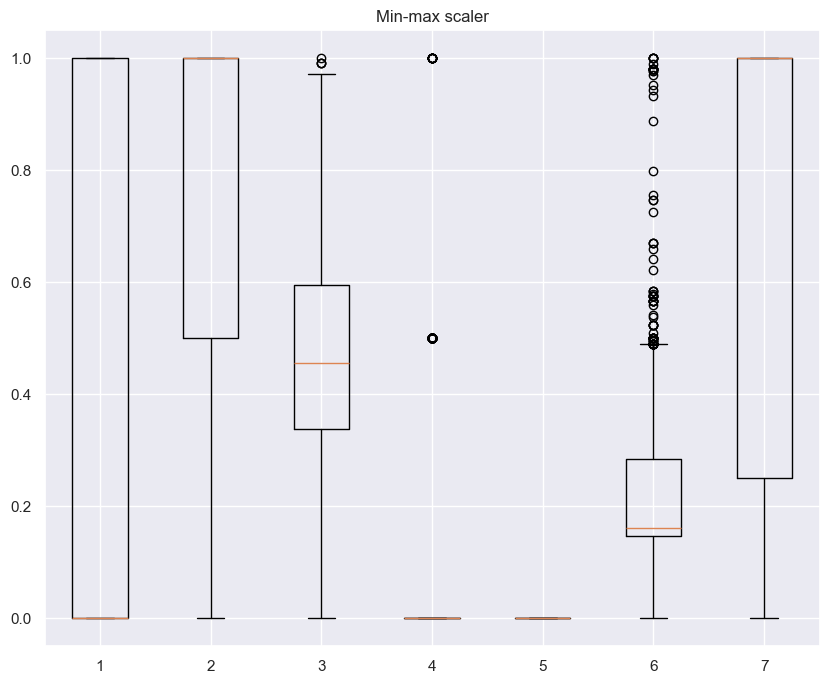

In [55]:
scaler=MinMaxScaler()
# Apply the scaler to the cleaned numerical DataFrame
scaled_data=pd.DataFrame(scaler.fit_transform(titanic_no_outliers), columns=numeric_titanic.columns)

# Display the head of the scaled data to verify
scaled_data.head(n=3)

plt.figure()
scaled_data.plot.hist(bins=30, alpha=0.5, figsize=(10, 8))
plt.show()

plt.figure(figsize=(10, 8))
plt.boxplot(scaled_data.to_numpy())
# plt.xticks(np.arange(1,len(scaled_data.columns)+1),scaled_data.columns,rotation=90)
plt.title("Min-max scaler")
plt.show()

<Figure size 640x480 with 0 Axes>

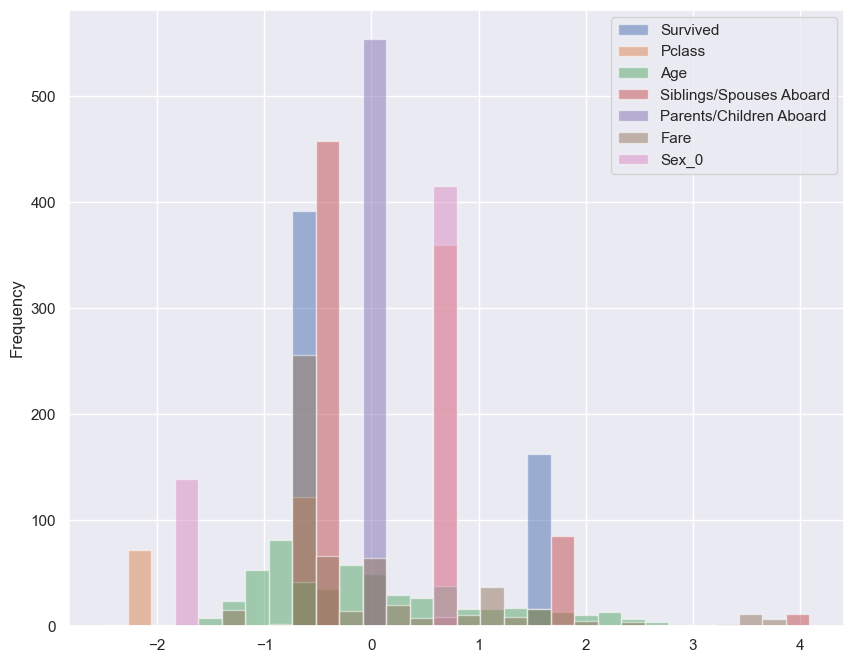

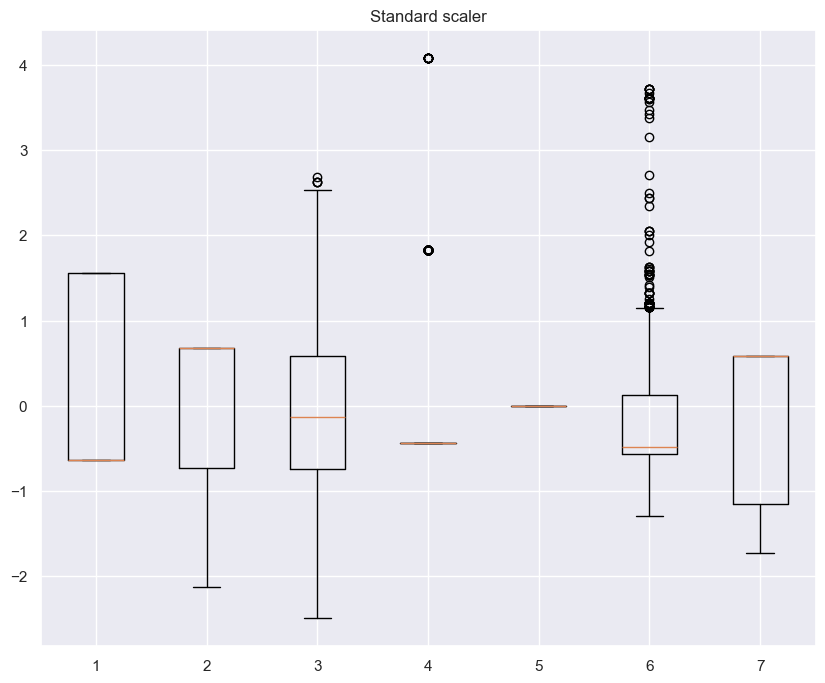

In [56]:
std_scaler=StandardScaler()

std_scaled_data=pd.DataFrame(std_scaler.fit_transform(titanic_no_outliers),columns=numeric_titanic.columns)

plt.figure()
std_scaled_data.plot.hist(bins=30, alpha=0.5, figsize=(10, 8))
plt.show()

plt.figure(figsize=(10, 8))
plt.boxplot(std_scaled_data.to_numpy())
# plt.xticks(np.arange(1,len(scaled_data.columns)+1),scaled_data.columns,rotation=90)
plt.title("Standard scaler")
plt.show()

Iterations: 7
Iterations: 2
[1 1 2 0 1 2 1 1 1 0 1 1 1 2 0 1 2 1 1 1 2 1 2 1 1 1 1 0 1 1 1 1 1 1 1 1 2
 2 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1 1 0 0 1 1 1 0 2 2 1 1 1
 1 1 1 1 2 0 1 1 1 0 0 1 0 2 1 1 2 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 1 1 2 1 0
 0 2 1 2 0 0 1 1 2 1 1 1 1 0 0 1 0 1 1 2 1 0 1 1 1 1 2 1 1 1 0 1 1 1 1 1 1
 1 1 2 1 0 1 1 1 1 1 1 2 1 1 0 1 0 1 2 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 2 1 2
 1 1 1 0 1 2 1 1 1 0 1 1 1 0 1 2 1 1 0 2 1 1 0 1 0 0 0 1 2 1 1 1 0 1 1 2 0
 1 1 0 1 1 1 1 1 1 0 2 1 0 1 1 1 1 1 1 2 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1
 1 0 2 1 1 0 2 0 2 1 1 1 1 1 1 2 2 1 2 1 1 2 0 1 2 0 2 0 0 0 1 1 0 0 1 1 2
 0 1 1 0 0 1 1 1 2 1 1 0 1 1 1 1 0 2 1 1 2 1 2 0 2 2 0 1 0 1 0 0 0 1 1 2 2
 1 1 2 1 1 1 2 0 1 0 1 0 1 1 1 0 2 2 1 1 1 0 1 0 2 2 1 0 1 1 0 0 2 2 0 1 0
 2 0 2 0 1 2 1 1 1 0 1 1 1 2 1 1 1 1 0 2 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 2 0
 1 1 0 0 2 2 1 1 1 1 1 1 1 1 1 1 0 0 1 0 2 1 1 2 0 2 2 2 2 1 0 1 1 0 1 0 0
 2 1 1 2 1 1 0 1 1 1 1 0 2 1 1 1 2 1 0 1 1 1 0 1 0 1 1 2 1 2 0 1 0 1 1 1

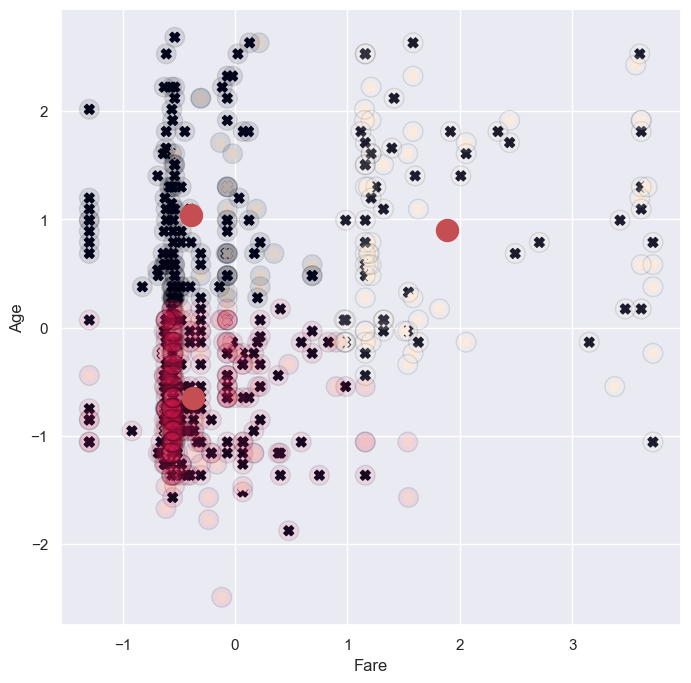

In [62]:
# klasteryzacja
X1=std_scaled_data[['Fare','Age']]
Y1=std_scaled_data['Survived']
titanic_kmeans=KMeans(n_clusters=3,init='random',n_init=10, max_iter=300)
titanic_kmeans.fit(X1)

print(f'Iterations: {titanic_kmeans.n_iter_}')
print(f'Iterations: {titanic_kmeans.n_features_in_}')

centroids=titanic_kmeans.cluster_centers_
clust=titanic_kmeans.labels_
print(clust)

plt.figure(figsize=(8,8))
plt.scatter(std_scaled_data[['Fare']],std_scaled_data[['Age']],c=Y1,marker='X',s=50)
plt.scatter(std_scaled_data[['Fare']],std_scaled_data[['Age']],c=clust,marker='o',alpha=0.1, s=200, edgecolor='black')
plt.xlabel("Fare")
plt.ylabel("Age")
plt.scatter(centroids[:,0],centroids[:,1],c='r',s=250)


In [67]:
Y1_np=Y1.astype(int).to_numpy()
mapping={0:1,1:0,2:1}
y_pred_mapped=np.array([mapping[c]for c in clust])

cm=confusion_matrix(Y1_np,y_pred_mapped)
print(cm)

[[245 147]
 [ 89  73]]


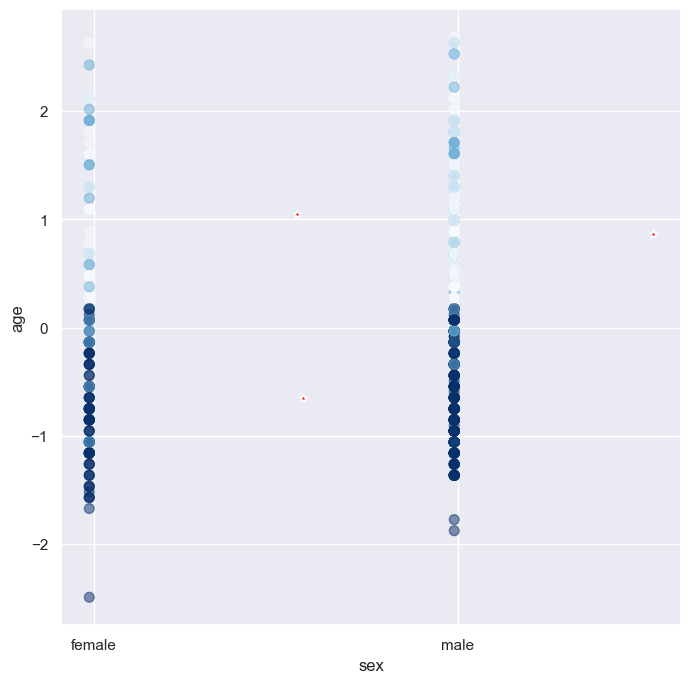

In [71]:
X1_scaled=std_scaled_data[['Sex_0','Age']]

titanic_kmeans=KMeans(n_clusters=3,init='random',n_init=10, max_iter=300)
titanic_kmeans.fit(X1)

X_plot=X1_scaled
clust_2=titanic_kmeans.labels_
centroids_scaled=titanic_kmeans.cluster_centers_

plt.figure(figsize=(8,8))
plt.scatter(X_plot['Sex_0'],X_plot['Age'],c=clust_2,marker='o',alpha=0.5,s=50,cmap='Blues')
plt.scatter(centroids_scaled[:,0],centroids_scaled[:,1],c='red',marker='*',edgecolors='white')
plt.xlabel('sex')
plt.ylabel('age')
plt.xticks(np.unique(X_plot['Sex_0'].round(1)), labels=['female','male'])
plt.show()

In [73]:
Y1_np=Y1.astype(int).to_numpy()
mapping={0:1,1:0,2:1}
y_pred_mapped=np.array([mapping[c]for c in clust_2])

cm=confusion_matrix(Y1_np,y_pred_mapped)
print(cm)

[[ 49 343]
 [ 48 114]]
